# Gamow window for the reaction $^7\mathrm{Be}+p$

As a first homework for Solar Neutrino Masterclass, I've deicided to do a theoretical part - calculate Gamow peak $E_0$ and Gamow window for the solar reaction

$$
{}^7\mathrm{Be}+p
$$

But to spend this masterclass productive I want to take a challenge as theoretician and try to figure out aboutthis mysterious data analysis. But calculations first.

$\hbar=c=1$ units are accounted.


## 1. Lecture inputs

As it was obtained on the lecture, thermal averaging that leads to Gamow peak and Gamow window is given by

\begin{equation}
<\sigma v>\sim S(E)\exp\left[-\frac{E}{kT}-\sqrt{\frac{E_G}{E}}\right].
\end{equation}

The first term suppresses large energies because particles in the Maxwell-Boltzmann tail are rare. The second term suppresses small energies because tunneling through the Coulomb barrier becomes very unlikely.

Their product has a maximum. **Gamow peak** is a maximum at $E_0$, **Gamow window** is an interval $E_0\pm \Delta E/2$.

I assume that $S(E)$ term is supressed, the arguments why need additional research as a part of different homework task.


## 2. Parameters for $^7\mathrm{Be}+p$

As an abstract notation we have reaction

$$a+b|_{a=^7\mathrm{B}, b=p}$$

with charges

$$
Z_a=4,\qquad Z_b=1.
$$

The reduced mass is

$$
\mu=\frac{m_a m_b}{m_a+m_b}.
$$

Using approximate nuclear masses,

$$
m_a\approx 7,\qquad m_b\approx 1,
$$

we get

$$
\mu=\frac{7}{8}.
$$

And in $eV$ units:

$$
\mu = \frac{7}{8}931.5 \mathrm{MeV} \approx 815 \mathrm{MeV}.
$$


## 3. Gamow energy

As it was obtained in lecture

$$
E_G = 2\mu(\pi\alpha Z_a Z_b)^2,
$$

where $\alpha=1/137$.

For $^7\mathrm{Be}+p$ we get:

$$
E_G = 2\cdot 815(\pi \frac{1}{137}4)^2 \mathrm{MeV}\approx 13.7 \mathrm{MeV}.
$$

(In lecture: $E_G=13692 \mathrm{keV}$)

## 4. Gamow peak position

The leading term in thermal averaging is exponential:

$$
\exp\left[-\frac{E}{kT}-\sqrt{\frac{E_G}{E}}\right]=\exp[-f(E)].
$$

Since the exponential function is monotonic, the maximum of it corresponds to the minimum of $f(E)$.

The condition is

$$
f'(E_0)=\frac{1}{kT}-\frac{1}{2}\sqrt{E_G}E_0^{-3/2}=0.
$$

This gives

$$
E_0=
\left[
\frac{E_G(kT)^2}{4}
\right]^{1/3}.
$$

For the solar core (as in lecture) I take

$$
kT\simeq 1.30\ \mathrm{keV}.
$$

Therefore

$$
E_0=\bigg(\frac{13700\cdot (1.3)^2}{4}\bigg)^{1/3}\approx 17.9 \mathrm{keV}.
$$

(In lecture: $E_0=18.0 \mathrm{keV}$)

## 5. Gamow window

If one wants to estimate the width of the Gamow window, one can expand $f(E)$ near $E_0$:

$$
f(E)\approx f(E_0)+\frac12 f''(E_0)(E-E_0)^2.
$$

This gives a Gaussian approximation to the peak. Explicit computations give

$$f''(E_0)=\frac{3}{4}\sqrt{E_G}E_0^{-5/2}=\bigg\{\sqrt{E_G}=\frac{2 E_0^{3/2}}{kT}\bigg\}=\frac{3}{2}\frac{1}{E_0 kT},$$

and we get

$$
f(E)\approx f(E_0)+\frac{3}{4}\frac{(E-E_0)^2}{E_0 kT}.
$$

For the diviation like $E_0\pm \Delta E/2$ usually (as far as I know) used this form of the exponential term:

$$
\exp\bigg[-\frac{4(E-E_0)^2}{\Delta E^2}\bigg].
$$

By comaparising it with my exponent I get:

$$
\Delta E= 4\sqrt{\frac{E_0 kT}{3}}= 4\sqrt{\frac{18\cdot 1.3}{3}}\approx 11 \mathrm{keV}.
$$

Then the Gamow roughlty is

$$
(E_0\pm 5.5) \mathrm{keV}.
$$


## 6. Plotting attempt

Let's use notation for the function

$$
G(E)=\exp\left[-\frac{E}{kT}-\sqrt{\frac{E_G}{E}}\right]
$$

and try to make a plot for it (AI-assisted. cause ususally I work in Maple, not Python).


E_G = 13700.00 keV
kT = 1.30 keV
E0 = 18.00 keV
Delta E = 11.00 keV
Gamow window ≈ 12.50 - 23.50 keV


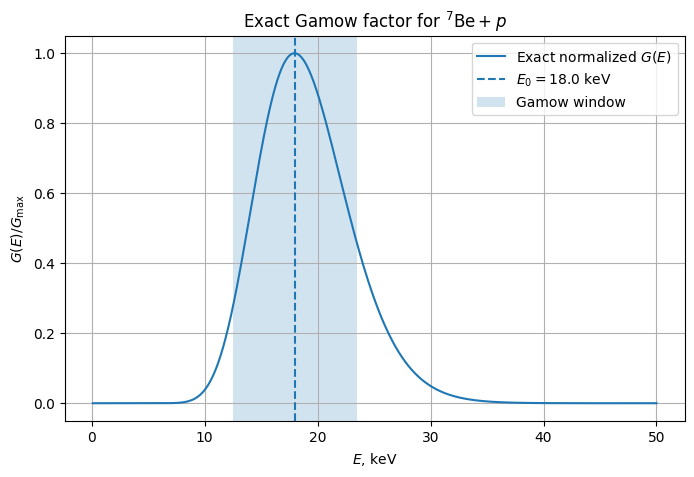

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. MANUAL PARAMETERS
# Все значения задаёшь руками
# ============================================================

# Gamow energy
E_G_keV = 13700.0   # keV

# Solar-core thermal energy
kT_keV = 1.30       # keV

# Already known Gamow peak position
E0_keV = 18      # keV

# Already known Gamow-window width
Delta_E_keV = 11 # keV

# If you want to mark the window manually
E_left_keV = 12.5  # keV
E_right_keV = 23.5 # keV

# Energy range for the plot
E_min_keV = 0.1
E_max_keV = 50.0
N_points = 1000

# ============================================================
# 2. EXACT GAMOW FACTOR
# ============================================================

E = np.linspace(E_min_keV, E_max_keV, N_points)

G = np.exp(-E / kT_keV - np.sqrt(E_G_keV / E))

# Normalize to the maximum, so the peak height is 1
G_norm = G / np.max(G)

# ============================================================
# 3. OUTPUT
# ============================================================

print(f"E_G = {E_G_keV:.2f} keV")
print(f"kT = {kT_keV:.2f} keV")
print(f"E0 = {E0_keV:.2f} keV")
print(f"Delta E = {Delta_E_keV:.2f} keV")
print(f"Gamow window ≈ {E_left_keV:.2f} - {E_right_keV:.2f} keV")

# ============================================================
# 4. PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(E, G_norm, label=r"Exact normalized $G(E)$")
plt.axvline(E0_keV, linestyle="--", label=fr"$E_0={E0_keV:.1f}$ keV")
plt.axvspan(E_left_keV, E_right_keV, alpha=0.2, label="Gamow window")

plt.xlabel(r"$E$, keV")
plt.ylabel(r"$G(E)/G_{\max}$")
plt.title(r"Exact Gamow factor for $^7\mathrm{Be}+p$")
plt.legend()
plt.grid(True)

plt.show()

## 7. Results

For the reaction

$$
{}^7\mathrm{Be}+p
$$

was obtained Gamow peak
$$
\boxed{E_0\simeq 18\ \mathrm{keV},}
$$

and Gamow window:

$$
\boxed{E\in (12.5,\ 23.5)\ \mathrm{keV}.}
$$

## Comments

Theory is great, but I want to challenge me with data analysis stuff, but it will be done tomorrow I guess.